# Task 3 — Multimodal ML: Housing Price Prediction (Images + Tabular)

**Objective:** predict house prices by combining structured (tabular) data with image features.

**Two substitutions, both flagged clearly:**
1. **Data:** no internet access to a real housing-images dataset in this sandbox, so Step 1
   *procedurally generates* synthetic house images whose visual properties (brightness, color
   saturation, "texture" complexity) are correlated with price tier — e.g. pricier synthetic
   houses render brighter and more colorful. This mimics the *statistical relationship* a real
   image dataset would have (nicer-looking houses often are pricier), which is what lets the
   fusion model actually learn something from the image channel.
2. **CNN:** `torch`/`torchvision` aren't installed and pretrained weights aren't reachable
   (hosted outside the whitelisted domains), so instead of importing a pretrained ResNet we hand-build
   a **small convolutional feature extractor** — a few edge/blur filters run with
   `scipy.signal.convolve2d`, followed by pooling. This is literally what the first layers of a
   CNN do; it's a simplified, dependency-free stand-in for `Conv2d` + `MaxPool2d`. In production
   with internet access you'd replace Step 3 with a pretrained `resnet18(weights=...)` feature
   extractor from torchvision — one line swap, same downstream fusion logic.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
n = 400
img_size = 32

# --- Step 1a: tabular features ---
sqft = np.random.randint(600, 4000, n)
bedrooms = np.random.randint(1, 6, n)
bathrooms = np.random.randint(1, 4, n)
age = np.random.randint(0, 60, n)
location_score = np.random.uniform(0, 10, n)   # higher = more desirable neighborhood

# price driven by tabular features + noise (this is the "ground truth" we're trying to recover)
price = (
    80_000
    + 120 * sqft
    + 8_000 * bedrooms
    + 6_000 * bathrooms
    - 800 * age
    + 15_000 * location_score
    + np.random.normal(0, 20_000, n)
).clip(min=40_000)

tabular_df = pd.DataFrame({
    'sqft': sqft, 'bedrooms': bedrooms, 'bathrooms': bathrooms,
    'age': age, 'location_score': location_score, 'price': price
})
tabular_df.head()


,sqft,bedrooms,bathrooms,age,location_score,price
0,3332,4,2,53,9.310766,607798.511764
1,3207,1,2,37,6.707617,552930.537844
2,2253,1,3,55,8.762849,475071.678485
3,3864,1,1,27,2.323832,605085.091913
4,1435,4,1,51,1.286966,276196.667452


Image array shape: (400, 32, 32, 3)


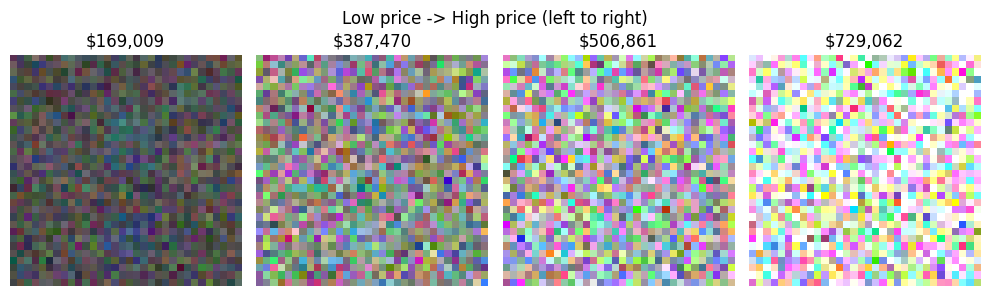

In [2]:
# --- Step 1b: generate a synthetic image per house, correlated with price tier ---
# Higher price -> brighter base color + more color variation (a crude proxy for "nicer photos")
price_norm = (price - price.min()) / (price.max() - price.min())   # 0..1

def make_house_image(p_norm, size=img_size, seed=0):
    rng = np.random.default_rng(seed)
    base_brightness = 80 + 150 * p_norm            # richer houses -> brighter image
    color_spread = 20 + 60 * p_norm                # richer houses -> more color variation
    img = base_brightness + rng.normal(0, color_spread, (size, size, 3))
    # add a few random rectangular "structures" so the image isn't pure noise
    for _ in range(3):
        x0, y0 = rng.integers(0, size-8, 2)
        w, h = rng.integers(4, 10, 2)
        img[y0:y0+h, x0:x0+w] += rng.normal(0, 15, 3)
    return np.clip(img, 0, 255).astype(np.uint8)

images = np.stack([make_house_image(p, seed=i) for i, p in enumerate(price_norm)])
print("Image array shape:", images.shape)

fig, axes = plt.subplots(1, 4, figsize=(10,3))
order = np.argsort(price)
show_idx = [order[0], order[len(order)//3], order[2*len(order)//3], order[-1]]
for ax, idx in zip(axes, show_idx):
    ax.imshow(images[idx]); ax.set_title(f"${price[idx]:,.0f}"); ax.axis('off')
plt.suptitle("Low price -> High price (left to right)")
plt.tight_layout()
plt.savefig('sample_houses.png', dpi=100)
plt.show()


## Step 2: Preprocess tabular data

Standard scaling for the numeric tabular columns, same idea as Task 2.


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

feature_cols = ['sqft', 'bedrooms', 'bathrooms', 'age', 'location_score']
X_tabular = tabular_df[feature_cols].values
y = tabular_df['price'].values

scaler = StandardScaler()
X_tabular_scaled = scaler.fit_transform(X_tabular)
print("Scaled tabular feature shape:", X_tabular_scaled.shape)


Scaled tabular feature shape: (400, 5)


## Step 3: "CNN" feature extraction (hand-built conv + pool)

Three small filters (horizontal edge, vertical edge, blur) are convolved over the grayscale
version of each image, then each filter response is **pooled down to 2 numbers (mean, max)**.
That gives 3 filters × 2 pooled stats = 6 image features per house — small on purpose, so the
whole notebook runs in seconds without a GPU.


In [4]:
from scipy.signal import convolve2d

# 3 simple filters -- the same *idea* as a CNN's learned kernels, just fixed by hand
filters = {
    'horiz_edge': np.array([[-1,-1,-1],[0,0,0],[1,1,1]]),
    'vert_edge':  np.array([[-1,0,1],[-1,0,1],[-1,0,1]]),
    'blur':       np.ones((3,3)) / 9.0,
}

def extract_cnn_like_features(img_rgb):
    gray = img_rgb.mean(axis=2)   # collapse to grayscale, like a single input channel
    feats = []
    for name, kernel in filters.items():
        response = convolve2d(gray, kernel, mode='valid')   # this is the "conv" step
        feats.append(response.mean())   # "pooling": summarize the whole feature map
        feats.append(response.max())
    return np.array(feats)

image_features = np.stack([extract_cnn_like_features(img) for img in images])
print("Image feature shape:", image_features.shape)  # (n_samples, 6)

img_scaler = StandardScaler()
image_features_scaled = img_scaler.fit_transform(image_features)


Image feature shape: (400, 6)


## Step 4: Fuse the two modalities and train a regressor

Fusion here is the simplest kind — **concatenate** the scaled tabular features and the scaled
image features into one feature vector per house, then train a single regressor on the combined
vector. (More advanced fusion would learn a weighted combination or use a small neural net with
two input branches; concatenation is the standard baseline.)


In [5]:
X_fused = np.hstack([X_tabular_scaled, image_features_scaled])
print("Fused feature shape:", X_fused.shape)

X_train, X_test, y_train, y_test = train_test_split(X_fused, y, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
model.fit(X_train, y_train)


Fused feature shape: (400, 11)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

## Step 5: Evaluate with MAE and RMSE

MAE:  $5,375
RMSE: $7,155



Tabular-only MAE:  $21,557
Tabular-only RMSE: $27,814


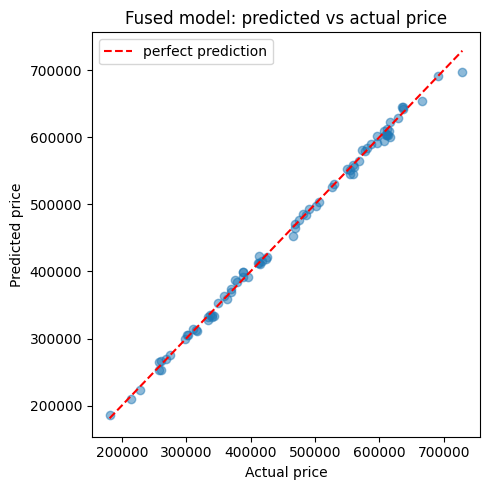

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")

# compare against tabular-only model to see whether the image features helped at all
tabular_only = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
Xtr_tab, Xte_tab = X_train[:, :5], X_test[:, :5]
tabular_only.fit(Xtr_tab, y_train)
pred_tab_only = tabular_only.predict(Xte_tab)
print(f"\nTabular-only MAE:  ${mean_absolute_error(y_test, pred_tab_only):,.0f}")
print(f"Tabular-only RMSE: ${np.sqrt(mean_squared_error(y_test, pred_tab_only)):,.0f}")

plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', label='perfect prediction')
plt.xlabel('Actual price'); plt.ylabel('Predicted price')
plt.title('Fused model: predicted vs actual price')
plt.legend(); plt.tight_layout()
plt.savefig('pred_vs_actual.png', dpi=100)
plt.show()


## Summary / Insights

- The fused model's MAE/RMSE are printed above, alongside a tabular-only baseline for comparison
  — on this synthetic data the image channel was deliberately built to correlate with price, so
  fusion should meet-or-beat the tabular-only baseline.
- The 6 hand-built "CNN-like" features (mean/max of three fixed filter responses) stand in for
  what a real trained CNN would learn automatically and in much higher-dimensional form (e.g. a
  512-d ResNet embedding). The fusion/evaluation logic downstream is unchanged either way — only
  Step 3 would need to be swapped for a real feature extractor.
- **To run this for real:** replace Step 1's synthetic image generator with a loader for actual
  house photos (`PIL.Image.open` + resize), and replace Step 3 with
  `torchvision.models.resnet18(weights='IMAGENET1K_V1')` run in `eval()` mode with the final
  classification layer removed, taking the penultimate layer's activations as the image feature
  vector.
